In [1]:
import sys
sys.path.append('../src')

from typing import Sequence

import numpy as np
from numpy.typing import NDArray

import jax
from jax import random
import jax.numpy as jnp

import pandas as pd

import numpyro
from numpyro import distributions as dist
from numpyro.contrib.hsgp.laplacian import eigenfunctions
from numpyro.contrib.hsgp.spectral_densities import diag_spectral_density_squared_exponential
from numpyro.infer import MCMC, Predictive
from numpyro.infer.initialization import init_to_median

# Custom modules
from numpyro_utils import fit_mcmc, posterior_predictive_mcmc
import visuals

import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep')

## Generate synthetic data

In [2]:
def se_kernel(
    X: jax.Array,
    Z: jax.Array,
    amplitude: float,
    length: float,
    noise: float | None,
    jitter=1.0e-6,
) -> jax.Array:
  """Squared exponential kernel function."""
  r = jnp.linalg.norm(X[:, jnp.newaxis] - Z, axis=-1)
  delta = (r / length) ** 2
  k = (amplitude**2) * jnp.exp(-0.5 * delta)
  if noise is None:
    return k
  else:
    return k + (noise**2 + jitter) * jnp.eye(X.shape[0])

In [3]:
def sample_grid_and_data(
    N_grid: int,
    N: int,
    L: float,
    amplitude: float,
    lengthscale: float,
    noise: float,
    key: int,
    D: int,
) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array]:
    """Sample N_grid ** D points from noiseless function and N noisy data points from a GP."""

    # draw points on a grid for plotting surface of the noiseless function
    x_linspace = jnp.linspace(-L, L, N_grid)
    x_mesh = jnp.meshgrid(*[x_linspace for _ in range(D)])
    X_grid = jnp.concatenate([x_mesh[i].ravel()[..., None] for i in range(D)], axis=1)

    # draw data points from a uniform distribution on the support of the grid
    X = random.uniform(key, shape=(N, D), minval=-L, maxval=L)

    # concatenate grid and data points
    X_all = jnp.concatenate([X_grid, X], axis=0)

    # sample from the GP
    cov = se_kernel(X_all, X_all, amplitude, lengthscale, 0.0)  # noiseless
    _, key = random.split(key)
    _y = random.multivariate_normal(key, mean=jnp.zeros(cov.shape[0]), cov=cov, method='svd')

    # separate the grid and data points
    y_grid = _y[0 : N_grid**D].reshape((N_grid,) * D)
    _, key = random.split(key)
    y = _y[N_grid**D :] + (
        random.normal(key, shape=(N,)) * noise
    )  # add noise to the data points

    y_mean = y.mean()

    return X_grid, y_grid - y_mean, X, y - y_mean

In [4]:
D = 2
N_grid = 25
N = 1_000
L = 3.0
amplitude = 1.0
lengthscale = 2.0
noise = 0.5
seed = 0
key = jax.random.key(seed)

X_grid, y_grid, X, y = sample_grid_and_data(
  N_grid, N, L, amplitude, lengthscale, noise, key, D
)

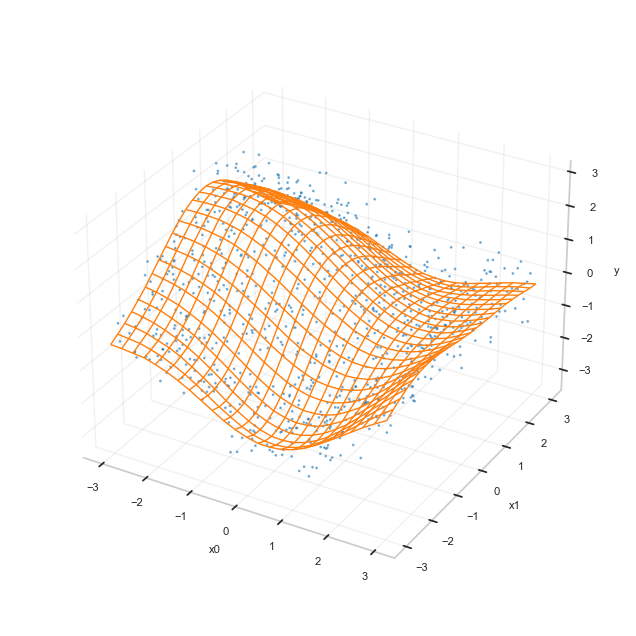

In [5]:
plot_surface = visuals.plot_surface_scatter(N_grid, X_grid, y_grid, X, y)
plt.show()

In [6]:
tr_frac = 0.8  # train on data contained within the inner tr_frac fraction of the domain
tr_idx = ((X > -L * tr_frac) & (X < L * tr_frac)).sum(axis=1) == D
tr_idx_grid = ((X_grid > -L * tr_frac) & (X_grid < L * tr_frac)).sum(axis=1) == D

X_train = X[tr_idx]  # train on values set away from the edges
X_test = X[~tr_idx]
y_train = y[tr_idx]
y_test = y[~tr_idx]

In [8]:
@jax.tree_util.register_pytree_node_class
class HSGPModel:
  def __init__(self, m: int, L: float) -> None:
    self.m = m
    self.L = L

  def model(
      self,
      X: jax.Array,
      y: jax.Array | None = None,
  ):
    amplitude = numpyro.sample('amplitude', dist.LogNormal(0, 1))
    length = numpyro.sample('lengthscale', dist.Exponential(1).expand([len(self.m)]))
    noise = numpyro.sample('noise', dist.LogNormal(0, 1))

    phi = eigenfunctions(x=X, ell=self.L, m=self.m)
    spd = jnp.sqrt(
        diag_spectral_density_squared_exponential(
            alpha=amplitude, length=length, ell=self.L, m=self.m, dim=2
        )
    )
    with numpyro.plate('basis', phi.shape[-1]):
      beta = numpyro.sample('beta', dist.Normal(0, 1))
    
    f = numpyro.deterministic('f', phi @ (spd * beta))

    site = 'y' if y is not None else 'y_test'
    numpyro.sample(site, dist.Normal(f, noise), obs=y)

  def tree_flatten(self):
    children = ()
    aux_data = (
      self.L,
      self.m
    )
    return (children, aux_data)
  
  @classmethod
  def tree_unflatten(cls, aux_data, children):
    return cls(*children, **aux_data)

In [9]:
hsgp_m = HSGPModel(m=[5, 5], L=[L*2.5, L*2.5])
hsgp_mcmc = fit_mcmc(
  0,
  hsgp_m.model,
  X=X_train,
  y=y_train,
  num_warmup=500,
  num_samples=500,
  target_accept_prob=0.95,
  init_strategy=init_to_median(num_samples=25)
)

/Users/shozendan/Imperial/high_res_brc/notebooks/../src/numpyro_utils.py:24: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1000/1000 [00:01<00:00, 709.56it/s, 127 steps of size 2.94e-02. acc. prob=0.95]


In [10]:
idata = az.from_numpyro(hsgp_mcmc)
az.summary(idata, var_names=["amplitude", "lengthscale", "noise"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
amplitude,2.788,2.477,0.553,6.420,0.080,0.057,1029.0,1088.0,1.0
lengthscale[0],1.104,0.532,0.192,2.044,0.014,0.010,1258.0,938.0,1.0
lengthscale[1],0.965,0.507,0.104,1.842,0.014,0.010,1220.0,1221.0,1.0
noise,0.498,0.014,0.472,0.522,0.000,0.000,2285.0,1389.0,1.0


In [11]:
def plot_fit_result(
    N_post: int, post: dict[str, jax.Array], q_lower: float = 0.1, q_upper: float = 0.9
):
    ci = np.quantile(post["y_test"], jnp.array([q_lower, q_upper]), axis=0)
    if D == 1:
        ci_lower, ci_upper = ci[0, :], ci[1, :]
        test_ind = (X < -L * tr_frac) | (X > L * tr_frac)
        ax = visuals.plot_line_scatter(
            X_grid,
            y_grid,
            X,
            y,
            test_ind=test_ind,
            post_y=post["f"][0:N_post, :],
            post_alpha=0.1,
            point_alpha=0.15,
            v_lines=[-L * tr_frac, L * tr_frac],
            ci=(ci_lower, ci_upper),
            fig_size=5.0,
        )
    elif D == 2:
        # compute confidence intervals at the edges of the grid
        yz_ind1 = X_grid[:, 0] == L
        yz_lower1 = ci[0, :][yz_ind1]
        yz_upper1 = ci[1, :][yz_ind1]
        yz_ind2 = X_grid[:, 0] == -L
        yz_lower2 = ci[0, :][yz_ind2]
        yz_upper2 = ci[1, :][yz_ind2]

        xz_ind1 = X_grid[:, 1] == L
        xz_lower1 = ci[0, :][xz_ind1]
        xz_upper1 = ci[1, :][xz_ind1]
        xz_ind2 = X_grid[:, 1] == -L
        xz_lower2 = ci[0, :][xz_ind2]
        xz_upper2 = ci[1, :][xz_ind2]

        ax = visuals.plot_surface_scatter(
            N_grid=N_grid,
            X_grid=X_grid,
            y_grid=y_grid,
            X=X,
            y=y,
            test_ind=~tr_idx,
            post_y=post["f"][0:N_post, :],
            post_alpha=0.1,
            xy_annotate_lines=[
                ((-L * tr_frac, -L * tr_frac), (-L * tr_frac, L * tr_frac)),
                ((-L * tr_frac, L * tr_frac), (L * tr_frac, L * tr_frac)),
                ((L * tr_frac, L * tr_frac), (-L * tr_frac, L * tr_frac)),
                ((L * tr_frac, -L * tr_frac), (-L * tr_frac, -L * tr_frac)),
            ],
            yz_lines=[
                (X_grid[yz_ind1, 1], yz_lower1, L),
                (X_grid[yz_ind1, 1], yz_upper1, L),
                (X_grid[yz_ind2, 1], yz_lower2, -L),
                (X_grid[yz_ind2, 1], yz_upper2, -L),
            ],
            xz_lines=[
                (X_grid[xz_ind1, 0], xz_lower1, L),
                (X_grid[xz_ind1, 0], xz_upper1, L),
                (X_grid[xz_ind2, 0], xz_lower2, -L),
                (X_grid[xz_ind2, 0], xz_upper2, -L),
            ],
            y_wireframe_alpha=0.4,
            ci_alpha=0.75,
        )
    return ax

In [12]:
post_y = posterior_predictive_mcmc(2, hsgp_m.model, hsgp_mcmc, X=X_grid)

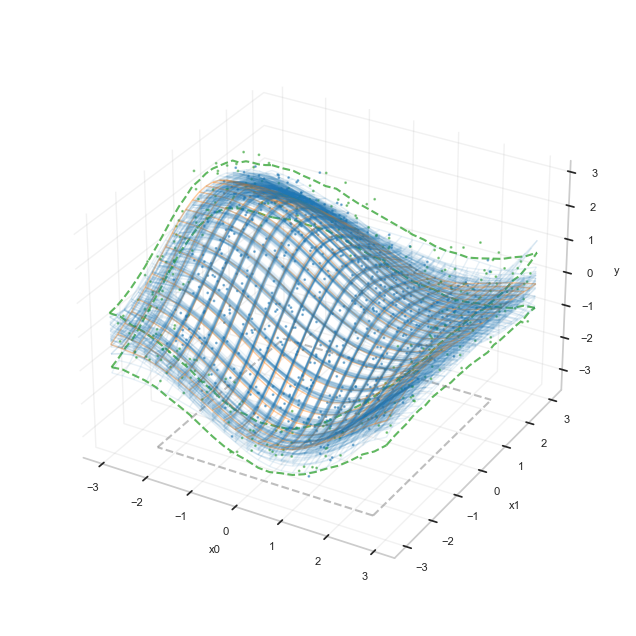

In [13]:
plot_fit_result(20, post_y)
plt.show()